# Ropedia Academy — C3 · Video understanding backbones: SlowFast & VideoMAE

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChaoYue0307/ropedia-academy/blob/main/notebooks/C3.ipynb)

> **Runs both video paradigms and visualizes them: the VideoMAE tube mask as a patch grid and the SlowFast two-rate frame sampling as an event plot.**
>
> 运行两种视频范式并可视化：把 VideoMAE 管状掩码画成块网格，把 SlowFast 双速率抽帧画成事件图。

This is the lesson's core example — **self-contained and runnable end to end**. It builds toy tensors, performs the lesson's key computation, and **visualizes the result with matplotlib** (the plot renders inline below the cell), so you learn the concept by executing and *seeing* it.

Colab's default runtime already includes `torch`, `numpy`, `networkx`, and `matplotlib`, so just press **Run all** — every cell goes green and a figure appears. Sizes are shrunk to run on CPU; swap in a real batch and the same code scales up.

🔗 Full lesson (with the interactive demo & key terms): https://chaoyue0307.github.io/ropedia-academy/lesson/C3

SlowFast fused feature: (1, 64, 4, 56, 56) | masked 90% of patches


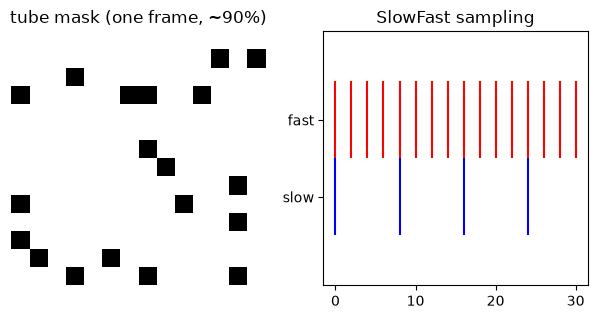

In [1]:
import torch, torch.nn as nn, matplotlib.pyplot as plt
# Two video paradigms: SlowFast two-rate fusion + VideoMAE tube masking.

# ---------- INPUT: a 32-frame clip (B, C, T, H, W) ----------
clip = torch.randn(1, 3, 32, 56, 56)

# ---------- MODEL: SlowFast pathways + a high-ratio tube mask ----------
slow, fast = clip[:, :, ::8], clip[:, :, ::2]         # few hi-detail vs many lo-capacity
slow_net, fast_net, lateral = nn.Conv3d(3,64,1), nn.Conv3d(3,8,1), nn.Conv3d(8,64,1)
fused = slow_net(slow) + lateral(fast_net(fast)[:, :, ::4])
T, side = 16, 14; N = side*side; keep = int(0.10 * N)
vis = torch.randperm(N)[:keep]
mask = torch.ones(T, N, dtype=torch.bool); mask[:, vis] = False        # same tube every frame

# ---------- OUTPUT: feature shape + tube mask grid + frame sampling ----------
print("SlowFast fused feature:", tuple(fused.shape),
      f"| masked {mask.float().mean()*100:.0f}% of patches")
fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.3))
ax[0].imshow(mask[0].reshape(side, side), cmap='gray'); ax[0].set_title("tube mask (one frame, ~90%)")
ax[0].axis('off')
ax[1].eventplot([torch.arange(0,32,8).tolist(), torch.arange(0,32,2).tolist()], colors=['b','r'])
ax[1].set_yticks([0,1]); ax[1].set_yticklabels(['slow','fast']); ax[1].set_title("SlowFast sampling")
plt.show()

### Where to go next

- Swap the toy tensors for a real batch and watch the shapes flow through.
- Open the matching lesson for the math and an interactive figure: https://chaoyue0307.github.io/ropedia-academy/lesson/C3
- Browse every notebook: https://github.com/ChaoYue0307/ropedia-academy/tree/main/notebooks